# **MLP con `scikit-learn`**

### **Esquema del MLP**

Dado un conjunto de datos de entrenamiento

$$
D_{train}=\{\vec{x}_i \in \mathbb{R}^d, y_i \in Ω\}_{i=1}^N,
$$

en donde $Ω$ es un conjunto de clases de cardinalidad $C$.

La red neuronal MLP para un problema de clasificación es un modelo que, mediante una función $\hat{f}$ dependiente de los vectores de características y de los vectores de pesos, predice una etiqueta $\hat{y}$, que puede coincidir o ser diferente de la etiqueta real $y$:

$$
\hat{f} (\vec{x}, \vec{w}) = \hat{y}
$$


### **El problema de optimización**

En `scikit-learn` la métrica asociada para evaluar el error del modelo con respecto a las predicciones (etiquetas) es la función de costo conocida como cross-entropy:

$$
L(\vec{y}, \hat{\vec{y}})=\frac{1}{N}\sum _{i=1} ^N L(y_i, \hat{y_i})
$$

En donde para clasificación binaria

$$
L(y_i, \hat{y_i}) = -[y_i log (\hat{y_i})+(1-y_i) log(1-\hat{y_i})]
$$

Y para multiclase

$$
L(y_i, \hat{y_i}) = - \sum_{i=1}^{C} y_i \log(\hat{y}_i)
$$

Pero también se incluye un término de regularización $L_2$ que penaliza los valores grandes de la magnitud de los pesos y resuelve el overfitting, conocido como *Weight Decay*:

$$
Weight Decay= \lambda \sum _{l=1} ^L ||\vec{w}_l||^2
$$

Con $l$ el índice que recorre el conjunto $\{1, \dots , L\}$, en donde $L$ es el número total de capas con parámetros entrenables. Al escalar $λ$ se le conoce como weight decay coefficient.

De tal forma que la función de costo total es:

$$
L_T (\vec{w})= L(\vec{y}, \hat{\vec{y}})+ Weight Decay
$$

Con base a lo anterior, el problema de optimización consiste en hallar el parámetro óptimo de pesos $\vec{w}^*$ tal que minimiza $L_T$:

$$
\vec{w}^* =ArgMin_{\vec{w}}\{L(\vec{y}, \hat{\vec{y}}) + \frac{\alpha}{2N} \sum _l ||\vec{w}_l||^2 \}
$$

### **Hiperparámetros en el MLP**

En `scikit-learn` los principales hiperparámetros a ajustar son:


* `activation`:

  Corresponde a la función de activación asociada al MLP. Recibe tres posibles valores en formato de cadena de texto, `'relu'` (valor por default), `'tanh'` o `'logistic'` (sigmoide).

* `alpha`:
  
  Es el parámetro de regularización $L_2$ y recibe un valor flotante. El valor típico suele estar entre `1e-6` y `1e-1`.

  El valor por default es `0.0001`.

* `solver`:

  Corresponde al algoritmo con el que se resuelve el problema de optimización planteado.
  
  Recibe tres posibles valores en formato de cadena de texto, `'sgd'` (gradiente de descenso estocástico) `'adam'` (un método de optimización basado en el gradiente de descenso estocástico propouesto por Kingma, Diederik y Jimmy Ba) o `'lbfgs'` (algoritmo de optimización de la familia de los métodos quasi-Newton).

  El valor por default es `'adam'`, y se recomienda para datasets grandes (del orden de miles de muestras de entrenamiento o más).

  Para datasets pequeños se recomienda`'lbfgs'`, pues converge más rápido.

* `learning_rate_init`:

  Corrsponde al valor inicial del ritmo o tasa de aprendizaje presente en la construcción del algoritmo del perceptrón. Controla el tamaño del paso en la actualización de pesos.
  
   Recibe un valor flotante, que por default es `0.001`.

   Este argumento solo se usa cuando `solver = 'adam'` o `'sgd'`. El método
   `'lbfgs'` lo ignora.

   El valor típico para este argumento suele estar entre `1e-5` y `1e-2`, o  `3e-5` y `3e-3`

* `max_iter`:

  Es el número máximo de iteraciones, pues el argumento `solver` itera hasta que converge o hasta alcanzar este número de iteraciones.

  Recibe un valor entero, que por default es `200`.

  El valor típico de este hiperparámetro suele ir desde `100` para datasets pequeños hasta más de `3000` para datasets grandes.

* `hidden_layer_sizes`:

  Es un hiperparámetro que define la estructura de la red. Recibe un arreglo desde una hasta $N$ dimensiones.
  
  La dimensión del arreglo corresponde al número de capas ocultas, cuyos valores de entrada corresponden a la dimensión de los vectores $\vec{h}$.
  
  Por ejemplo, dado $\vec{x} \in \mathbb{R}^d$, si `hidden_layer_sizes = (100, 50)`, el MLP tiene una estructura definida por $\vec{h}_0 \in \mathbb{R}^{100}$ y $\vec{h}_1 \in \mathbb{R}^{50}$.

  El valor por default es `hidden_layer_sizes = (100,)`.

  Un ajuste típico, por ejemplo, mediante GridSearchCV suele ser:
  
  `hidden_layer_sizes = [(20,), (50,), (100,), (50, 50), (100, 50)]`

  En la práctica, implementar tres o más capas no es tan frecuente usando `scikit-learn`, pues aumenta el riesgo de overfitting y el tiempo de entrenamiento.


### **Sintaxis en `scikit-learn`: MLP para clasificación**

    from sklearn.neural_network import MLPClassifier

    #Modelo:
    mlp = MLPClassifier(
    hidden_layer_sizes,
    activation,
    solver,
    alpha,
    learning_rate_init,
    max_iter,
    random_state)

    #Entrenamiento del modelo:
    mlp.fit(X_train, y_train)

    #Predicciones del modelo sobre el conjunto test:
    y_pred = mlp.predict(X_test)

Una consideración recomendada en la práctica para tener una convergencia más rápida es estandarizar las características.

Otro punto importante es que `MLPClassifier` solo trabaja con datos numéricos.


### **Código: MLP para clasificar la presencia de una enfermedad cardiaca**

Usando una base de datos que contiene información sobre enfermedades cardiacas en pacientes de diversas zonas del mundo, la finalidad de implementar una red MLP es realizar una clasificación binaria correspondiente a la presencia o ausencia de una enfermedad cardiaca.

Columnas del dataset:

* **id**: Identificación única para cada paciente.

* **age**: Edad del paciente en años.

* **dataset**: Lugar del estudio.

* **sex**: Sexo (variable binaria: Masculino/Femenino).

* **cp**: Tipo de dolor torácico (angina típica, angina atípica, no anginal, asintomático).

* **trestbps**: Presión arterial en reposo (en unidades $mmHg$ al momento de ingreso en el hospital).

* **chol**: Colesterol sérico en unidades $\frac{mg}{dL}$.

* **fbs**: Nivel de glucosa en ayunas > 120 $\frac{mg}{dL}$ (variable binaria: Verdadero/Falso).

* **restecg**: Resultados del electrocardiograma en reposo: normal, anomalía en ST-T, hipertrofia ventricular izquierda.

* **thalach**: Frecuencia cardíaca máxima alcanzada.

* **exang**: Angina inducida por el ejercicio (variable binaria: Verdadero/Falso).

* **oldpeak**: Depresión del segmento ST inducida por el ejercicio en relación con el reposo.

* **slope**: Pendiente del segmento ST en el ejercicio máximo.

* **ca**: Número de vasos principales (0-3) coloreados por fluoroscopía.

* **thal**: normal; defecto fijo; defecto reversible.

* **num**: Atributo predicho (variable binaria: enfermedad presente o ausente).



# **Importación del conjunto de datos**

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

from google.colab import drive
drive.mount('/content/drive')

file_path = '/content/drive/MyDrive/Colab Notebooks/Servicio Social/Cardiacas.xlsx'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
df=pd.read_excel(file_path, sheet_name = "enfermedadescardiacas")

display(df.head())
print('°°°°°°°°°°°°°°°°°°°°°°°°°°°°°°°°°°°°°°°°°°°°°°°°°°°')

print(df.info())
print('°°°°°°°°°°°°°°°°°°°°°°°°°°°°°°°°°°°°°°°°°°°°°°°°°°°')

print(df.shape)
print('°°°°°°°°°°°°°°°°°°°°°°°°°°°°°°°°°°°°°°°°°°°°°°°°°°°')

print(df.columns)

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145,233,True,lv hypertrophy,150,False,2.3,downsloping,0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160,286,False,lv hypertrophy,108,True,1.5,flat,3,normal,1
2,3,67,Male,Cleveland,asymptomatic,120,229,False,lv hypertrophy,129,True,2.6,flat,2,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130,250,False,normal,187,False,3.5,downsloping,0,normal,0
4,5,41,Female,Cleveland,atypical angina,130,204,False,lv hypertrophy,172,False,1.4,upsloping,0,normal,0


°°°°°°°°°°°°°°°°°°°°°°°°°°°°°°°°°°°°°°°°°°°°°°°°°°°
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 299 entries, 0 to 298
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        299 non-null    int64  
 1   age       299 non-null    int64  
 2   sex       299 non-null    object 
 3   dataset   299 non-null    object 
 4   cp        299 non-null    object 
 5   trestbps  299 non-null    int64  
 6   chol      299 non-null    int64  
 7   fbs       299 non-null    bool   
 8   restecg   299 non-null    object 
 9   thalch    299 non-null    int64  
 10  exang     299 non-null    bool   
 11  oldpeak   299 non-null    float64
 12  slope     299 non-null    object 
 13  ca        299 non-null    int64  
 14  thal      299 non-null    object 
 15  num       299 non-null    int64  
dtypes: bool(2), float64(1), int64(7), object(6)
memory usage: 33.4+ KB
None
°°°°°°°°°°°°°°°°°°°°°°°°°°°°°°°°°°°°°°°°°°°°°°°°°°°
(299, 16)
°°

# **Preprocesamiento**

In [ ]:
#Nos deshacemos de las columnas que no aportan información relevante al objetivo: id y dataset.
df=df.drop('id',axis=1)
display(df['dataset'].value_counts())
print('°°°°°°°°°°°°°°°°°°°°°°°°°°°°°°°°°°°°°°°°°°°°°°°°°°°')
df=df.drop('dataset',axis=1)

df.columns

,count
dataset,
Cleveland,297
Hungary,1
VA Long Beach,1


°°°°°°°°°°°°°°°°°°°°°°°°°°°°°°°°°°°°°°°°°°°°°°°°°°°


Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalch',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num'],
      dtype='object')

In [ ]:
#Definiendo el conjunto de datos
X = df.drop('num', axis=1)
y = df['num'] #num es la columna sobre padecimiento o no

#Identificando columnas numéricas y categóricas (MLPClassifier trabaja solammente con datos numéricos)
cols_cat = X.select_dtypes(include=['object']).columns
cols_num = X.select_dtypes(exclude=['object']).columns

In [ ]:
#Transformador: transformación mediante estandarización y OHE (para transformar los valores categóricos a numéricos)
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(transformers=[('num', StandardScaler(), cols_num), ('cat', OneHotEncoder(handle_unknown='ignore'), cols_cat)])

#División del conjunto de datos, 70%-30% train-test
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=170119, stratify=y)


# **El modelo MLP para el hiperparámetro `hidden_layer_sizes = (20, )`**

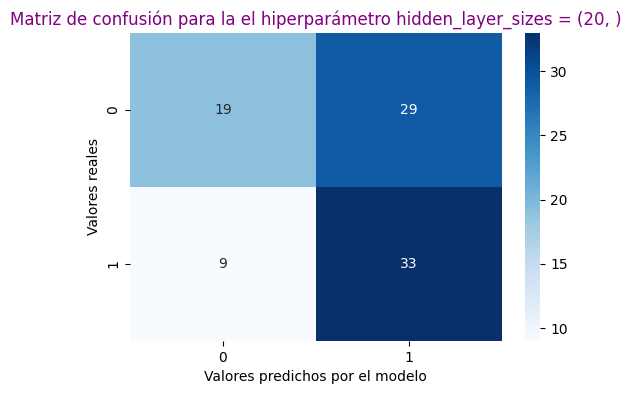

              precision    recall  f1-score   support

           0       0.68      0.40      0.50        48
           1       0.53      0.79      0.63        42

    accuracy                           0.58        90
   macro avg       0.61      0.59      0.57        90
weighted avg       0.61      0.58      0.56        90



In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, precision_score, f1_score, classification_report

import warnings
warnings.filterwarnings("ignore", category=UserWarning)

#MLP
mlp_20 = MLPClassifier(
hidden_layer_sizes = (20, ),
activation = 'relu',
solver = 'adam',
alpha = 1e-4,
learning_rate_init = 1e-4,
max_iter = 100,
random_state = 170119)

pipe_20 = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', mlp_20)])

#Entrenamiento y predicciones
pipe_20.fit(X_train, y_train)
y_pred_20 = pipe_20.predict(X_test)

#Matriz de confusión
CM_20 = confusion_matrix(y_test, y_pred_20)
plt.figure(figsize=(6, 4))
sns.heatmap(CM_20, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Valores predichos por el modelo')
plt.ylabel('Valores reales')
plt.title('Matriz de confusión para la el hiperparámetro hidden_layer_sizes = (20, )', color='purple')
plt.show()

#Métricas
print(classification_report(y_test, y_pred_20))





# **El modelo MLP para el hiperparámetro `hidden_layer_sizes = (50, )`**



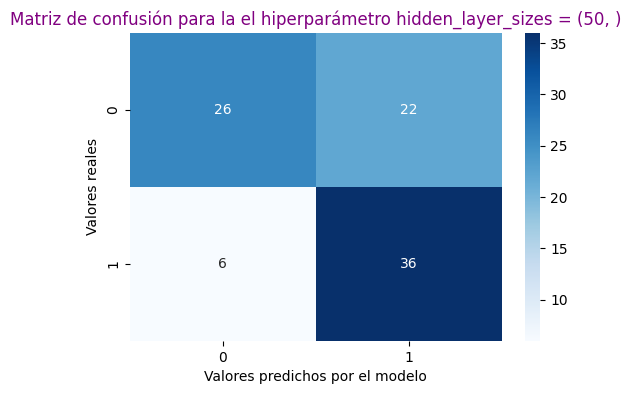

              precision    recall  f1-score   support

           0       0.81      0.54      0.65        48
           1       0.62      0.86      0.72        42

    accuracy                           0.69        90
   macro avg       0.72      0.70      0.69        90
weighted avg       0.72      0.69      0.68        90



In [ ]:
#MLP
mlp_50 = MLPClassifier(
hidden_layer_sizes = (50, ),
activation = 'relu',
solver = 'adam',
alpha = 1e-4,
learning_rate_init = 1e-4,
max_iter = 100,
random_state = 170119)

pipe_50 = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', mlp_50)])

#Entrenamiento y predicciones
pipe_50.fit(X_train, y_train)
y_pred_50 = pipe_50.predict(X_test)

#Matriz de confusión
CM_50 = confusion_matrix(y_test, y_pred_50)
plt.figure(figsize=(6, 4))
sns.heatmap(CM_50, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Valores predichos por el modelo')
plt.ylabel('Valores reales')
plt.title('Matriz de confusión para la el hiperparámetro hidden_layer_sizes = (50, )', color='purple')
plt.show()

#Métricas
print(classification_report(y_test, y_pred_50))

# **El modelo MLP para el hiperparámetro `hidden_layer_sizes = (100, )`**

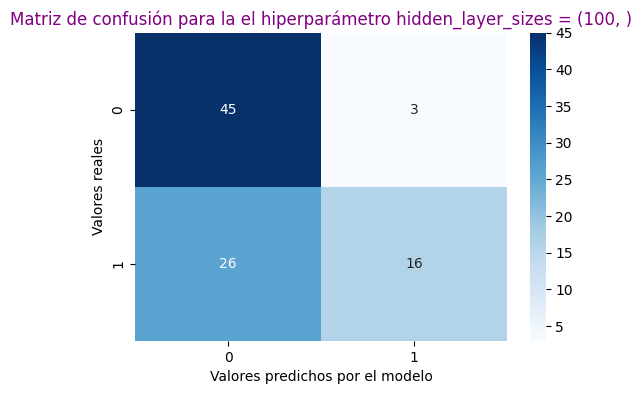

              precision    recall  f1-score   support

           0       0.63      0.94      0.76        48
           1       0.84      0.38      0.52        42

    accuracy                           0.68        90
   macro avg       0.74      0.66      0.64        90
weighted avg       0.73      0.68      0.65        90



In [ ]:
#MLP
mlp_100 = MLPClassifier(
hidden_layer_sizes = (100, ),
activation = 'relu',
solver = 'adam',
alpha = 1e-4,
learning_rate_init = 1e-4,
max_iter = 100,
random_state = 170119)

pipe_100 = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', mlp_100)])

#Entrenamiento y predicciones
pipe_100.fit(X_train, y_train)
y_pred_100 = pipe_100.predict(X_test)

#Matriz de confusión
CM_100 = confusion_matrix(y_test, y_pred_100)
plt.figure(figsize=(6, 4))
sns.heatmap(CM_100, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Valores predichos por el modelo')
plt.ylabel('Valores reales')
plt.title('Matriz de confusión para la el hiperparámetro hidden_layer_sizes = (100, )', color='purple')
plt.show()

#Métricas
print(classification_report(y_test, y_pred_100))

# **El modelo con mejores métricas`**

La métrica Recall suele priorizarse en situaciones en donde es mejor detectar un **False Positive** que un **False Negative**, por lo que fijarnos en ella es una buena forma de evaluar nuestro modelo para predecir la presencia de una enfermedad cardiaca.

El MLP con el hiperparámetro `hidden_layer_sizes = (50, )` es el mejor. Trabajar con un MLP de una capa oculta formada por 50 neuronas, arrojó la mejor métrica Recall, pues predijo solo 6 casos **False Negative**. Los otros dos modelos arrojaron 9 y 26 casos **False Negative**.

De las 90 muestras, el modelo con `hidden_layer_sizes = (50, )` detectó el 86% de los enfermos, mientras que los otros dos modelos detectaron el 79% y el 38%.